In [275]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit.circuit.library import LinearAmplitudeFunction
from qiskit_aer.primitives import Sampler
from qiskit_finance.circuit.library import LogNormalDistribution
from qiskit.circuit import ClassicalRegister
from qiskit_aer.primitives import Sampler

In [276]:
qubits = 8

def build_uncertainty_model(qubits, S0, vol, r, T):
    mu = (r - 0.5 * vol**2) * T + np.log(S0)
    sigma = vol * np.sqrt(T)  # std of log(ST)

    mean = np.exp(mu + 0.5 * sigma**2)
    var = (np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2)
    std = np.sqrt(var)

    low = max(0.0, mean - 3 * std)
    high = mean + 3 * std

    model = LogNormalDistribution(
        qubits, mu=mu, sigma=sigma**2, bounds=(low, high)
    )
    return model, low, high

We truncate the random variable on:

$$
[\text{low}, \text{high}] =
\left[
\max\!\bigl(0,\ \mathbb{E}[S_T] - 3\,\mathrm{Std}(S_T)\bigr),\ 
\mathbb{E}[S_T] + 3\,\mathrm{Std}(S_T)
\right].
$$

This is a heuristic to capture most of the probability mass.

In [277]:
def build_call_circuit(num_uncertainty_qubits, uncertainty_model, low, high, K, c_approx):
    K_eff = float(np.clip(K, low + 1e-9, high - 1e-9))

    breakpoints = [low, K_eff]
    slopes = [0, 1]
    offsets = [0, 0]
    f_min = 0
    f_max = max(0.0, high - K_eff)

    objective = LinearAmplitudeFunction(
        num_uncertainty_qubits,
        slopes,
        offsets,
        domain=(low, high),
        image=(f_min, f_max),
        breakpoints=breakpoints,
        rescaling_factor=0.25,
    )

    european_call = QuantumCircuit(objective.num_qubits)
    european_call.append(uncertainty_model, range(num_uncertainty_qubits))
    european_call.append(objective, range(objective.num_qubits))

    return european_call, objective, K_eff


$$
|x\rangle|0\rangle \;\longmapsto\; |x\rangle\Big(\sqrt{1-a(x)}\,|0\rangle + \sqrt{a(x)}\,|1\rangle\Big),
$$

so that

$$
\Pr(1\mid x)=a(x).
$$

A convenient choice is

$$
a(x)=\sin^2(\theta(x)),
$$

$$
\theta(x)=c_{\mathrm{approx}}\;\tilde f(x),
$$
The parameter `c_approx` (called `rescaling_factor` in the code) sets the scale of the rotation angles: smaller values keep the rotations gentle and typically improve the approximation, while larger values make the circuit more sensitive but can increase approximation error and gate cost.

$$
c_{\mathrm{approx}} \;\text{controls the scale of the rotation angles.}
$$


For a European call with strike \(K\), the payoff is
$$
f(x)=\max(x-K,0).
$$
The quantity computed in the code is the discrete expected payoff:
$$
\texttt{exact\_value}
= \sum_{i=0}^{2^n-1} p_i\, f(x_i)
= \sum_{i=0}^{2^n-1} p_i\,\max(x_i-K,0).
$$

In [278]:
def exact_call_value(uncertainty_model, K):
    x = uncertainty_model.values
    payoff = np.maximum(0, x - K)
    return float(np.dot(uncertainty_model.probabilities, payoff))



def measure_prob_one(circuit, qubits, shots=5000, seed=75):
    qc_meas = circuit.copy()            # classical bit
    c = ClassicalRegister(1, "c")
    qc_meas.add_register(c)
    qc_meas.measure(qubits, c[0])  # This objective (payoff) qubit is measured; P(c[0]=1) encodes the expected payoff (after post_processing).

    sampler = Sampler(run_options={"shots": shots, "seed": seed})
    res = sampler.run([qc_meas]).result()
    qd = res.quasi_dists[0]      
    return float(qd.get(1, 0.0))



We copy the quantum circuit and add a 1-bit classical register \(c\) to store the measurement outcome.  
We then measure the selected qubit into the classical bit \(c[0]\):

$$
\texttt{qc\_meas.measure(objective\_qubit,\; c[0])}.
$$

By running the measured circuit many times (shots), we estimate

$$
\hat a \approx \Pr(1)
$$

as the empirical frequency of observing outcome \(1\).  
Finally, we map this probability back to the expected payoff using the post-processing function:

$$
\widehat{\mathbb{E}[f(S_T)]}=\texttt{post\_processing}(\hat a).
$$

/var/folders/cw/dmc29yl132b0gt9jmntgvzlc0000gn/T/ipykernel_76469/1471549262.py:10: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  objective = LinearAmplitudeFunction(
/var/folders/cw/dmc29yl132b0gt9jmntgvzlc0000gn/T/ipykernel_76469/2896913738.py:23: DeprecationWarning: Sampler has been deprecated as of Aer 0.15, please use SamplerV2 instead.
  a_hat = measure_prob_one(european_call, qubits, shots=final_shots, seed=seed)
/var/folders/cw/dmc29yl132b0gt9jmntgvzlc0000gn/T/ipykernel_76469/1471549262.py:10: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  objective = LinearAm

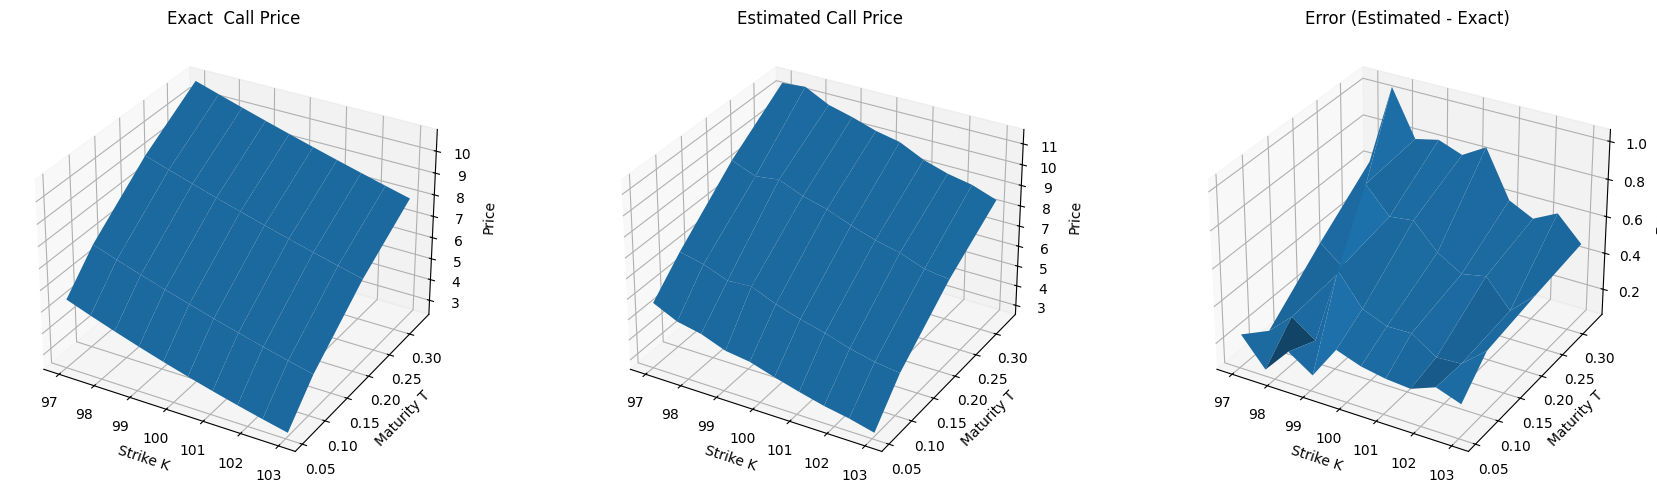

Objective qubit indices used (per T,K):
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [ ]:
def compute_surfaces(
    Ks, Ts,
    S0=100, vol=0.4, r=0.05,
    num_uncertainty_qubits=8,
    c_approx=0.25,
    final_shots=20000,
    probe_shots=2000,
    seed=75,
    discount=True,
):
    exact = np.zeros((len(Ts), len(Ks)))
    est   = np.zeros((len(Ts), len(Ks)))
    err   = np.zeros((len(Ts), len(Ks)))
    objq  = np.zeros((len(Ts), len(Ks)), dtype=int)

    for iT, T in enumerate(Ts):
        uncertainty_model, low, high = build_uncertainty_model(num_uncertainty_qubits, S0, vol, r, float(T))

        for iK, K in enumerate(Ks):
            european_call, objective, K_eff = build_call_circuit(num_uncertainty_qubits, uncertainty_model, low, high, float(K), c_approx)

            exact_value = exact_call_value(uncertainty_model, K_eff)
            a_hat = measure_prob_one(european_call, qubits, shots=final_shots, seed=seed)
            est_value = objective.post_processing(a_hat)

            if discount:
                disc = np.exp(-r * float(T))
                exact_value *= disc
                est_value *= disc

            exact[iT, iK] = exact_value
            est[iT, iK] = est_value
            err[iT, iK] = est_value - exact_value  # signed error (use abs if you prefer)

    return exact, est, err, objq


def plot_3_surfaces(Ks, Ts, exact, est, err):
    K_grid, T_grid = np.meshgrid(Ks, Ts)

    fig = plt.figure(figsize=(18, 5))

    ax1 = fig.add_subplot(131, projection="3d")
    ax1.plot_surface(K_grid, T_grid, exact, linewidth=0, antialiased=True)
    ax1.set_title("Exact  Call Price")
    ax1.set_xlabel("Strike K")
    ax1.set_ylabel("Maturity T")
    ax1.set_zlabel("Price")

    ax2 = fig.add_subplot(132, projection="3d")
    ax2.plot_surface(K_grid, T_grid, est, linewidth=0, antialiased=True)
    ax2.set_title("Estimated Call Price")
    ax2.set_xlabel("Strike K")
    ax2.set_ylabel("Maturity T")
    ax2.set_zlabel("Price")

    ax3 = fig.add_subplot(133, projection="3d")
    ax3.plot_surface(K_grid, T_grid, err, linewidth=0, antialiased=True)
    ax3.set_title("Error (Estimated - Exact)")
    ax3.set_xlabel("Strike K")
    ax3.set_ylabel("Maturity T")
    ax3.set_zlabel("Error")

    plt.tight_layout()
    plt.show()


Ks = np.linspace(97,103, 10)           
Ts = np.array([20/365, 40/365, 80/365, 120/365])  

exact, est, err, objq = compute_surfaces(
    Ks, Ts,
    S0=100, vol=0.4, r=0.05,
    num_uncertainty_qubits=8,
    c_approx=0.25,
    final_shots=20000,
    probe_shots=2000,
    seed=75,
    discount=True,   
)

plot_3_surfaces(Ks, Ts, exact, est, err)

